## Exercise Project 1 

Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)

Shape: `34k rows, 19 columns`

Target Variable: `sale_price`

Method: `Linear Regression`

Extra Tools: `Mlflow`



---

### Code

In [ ]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from skfeature.function.similarity_based import fisher_score
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from scipy import stats
from sklearn.preprocessing import OneHotEncoder
import mlflow
import mlflow.sklearn

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1| <bold style="background:yellow;color:black;">Data Cleaning </bold>|
|2| Feature Engineering|
|3| ML Implementation|
|4| Model Application|


#### Checking Shape

In [305]:
# Checking the amount of columns and rows.
df.shape

# That seems like a reasonable amount of data. Lots to work with.

(34439, 19)

#### Missing Values

In [306]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. 

# Dropping nan values.
df = df.dropna()

##### Dropping Columns

In [307]:
# Filtering out any rows which may be for commercial uses.
df[df['comarea'] > 0].shape

# Dropping columns that initially can be seen as redundant or irrelevant
df = df.drop(["borough_x", "block", "lot",'latitude','longitude'], axis=1)

In [318]:
df_original = df 

---



### Selecting Features

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Feature Engineering</bold>|
|3| ML Implementation|
|4| Model Application|

####  Truncating the Target Variable (OUTLIER/Skew Elimination)


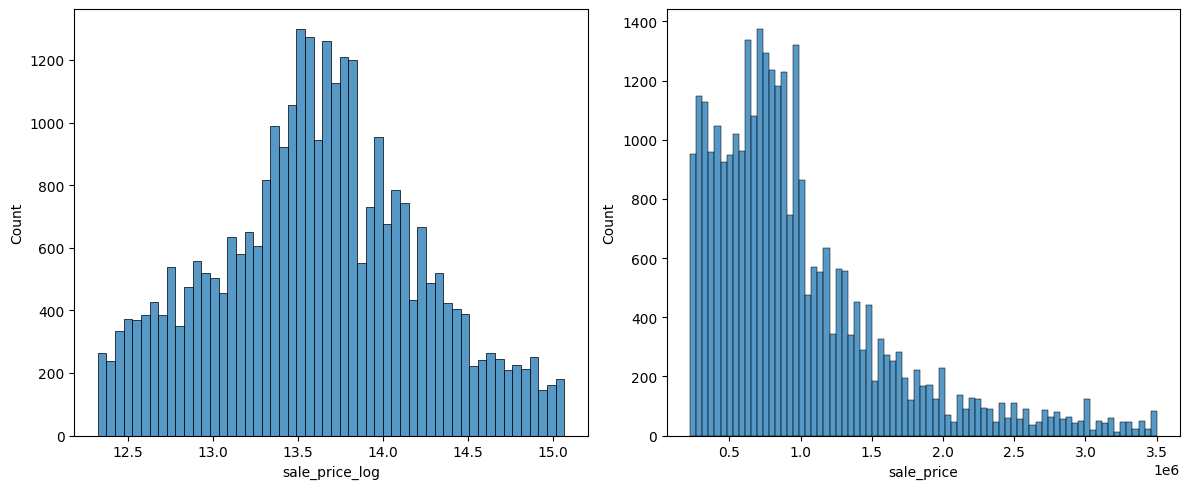

30861


In [ ]:
# Target variable cutoffs.
y_trunc_floor = 0.05
y_trunc_ceiling = 0.95

# Our target variable is EXTREMELY skewed.

# Second, alliviate some of the skewing via truncating the data.
# I like to use a multi-filtering approach for readability.

# Third, we'll use log transformation(reduces exponential distribution)
df['sale_price_log'] = df['sale_price'].apply(lambda x: np.log1p(x))


df = df[
    (df['sale_price_log'] >= df['sale_price_log'].quantile(q=y_trunc_floor)) &
    (df['sale_price_log'] <= df['sale_price_log'].quantile(q=y_trunc_ceiling))
    ]


# Creates a plot with multiple subplots.
# 1 row, 3 columns.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df, x='sale_price_log', ax=axes[0])
sns.histplot(df, x='sale_price', ax=axes[1])
# Prevents overlap between graphs
plt.tight_layout()

# Shows the plots
plt.show()


# RESULTS:
# Not great. But it's probably the best we can get.
# We'll have to wait until Tuomas can give some pointers.

# SANITY CHECK:
# Let's check how many rows we have left.
print(df.shape[0])

30861


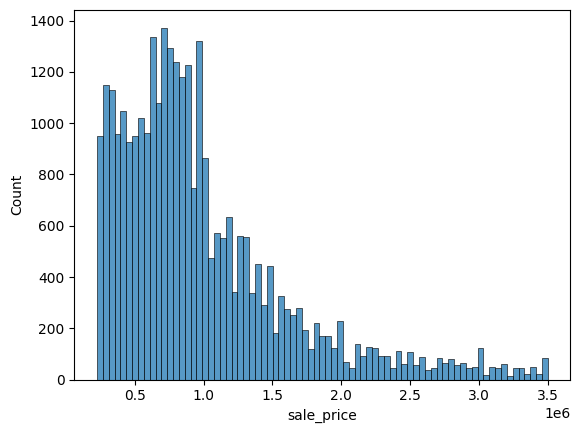

In [309]:


# df = df[
#     (df['sale_price'] >= df['sale_price'].quantile(q=y_trunc_floor)) &
#     (df['sale_price'] <= df['sale_price'].quantile(q=y_trunc_ceiling))
#     ]

# Finally, plot over the previous distribution.
sns.histplot(df, x='sale_price')

# RESULTS:
# Not great. But it's probably the best we can get.
# We'll have to wait until Tuomas can give some pointers.

# SANITY CHECK:
# Let's check how many rows we have left.
print(df.shape[0])

#### Partial Correlation Matrix (Continuous Columns only)

<Axes: >

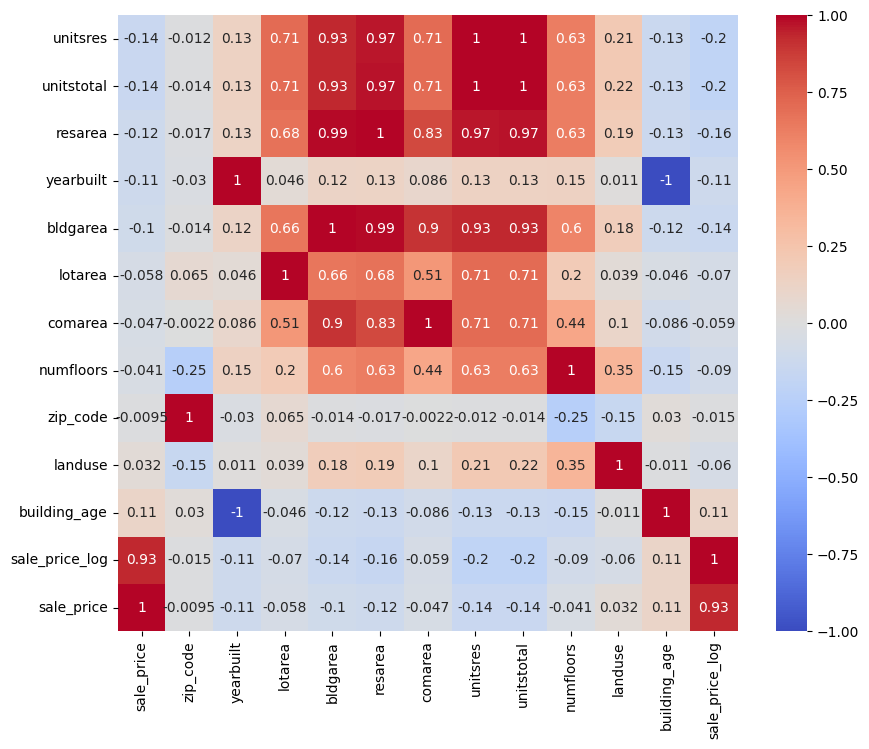

In [310]:
# Pearson correlation heatmap (matrix)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
plt.figure(figsize=(10,8))
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# df = df[['sale_price', 'resarea', 'bldgarea','unitsres','unitstotal','numfloors', 'landuse','borough_y','bldgclass']]


#### 

#### Changing Categorical Columns to Numbers

<Axes: >

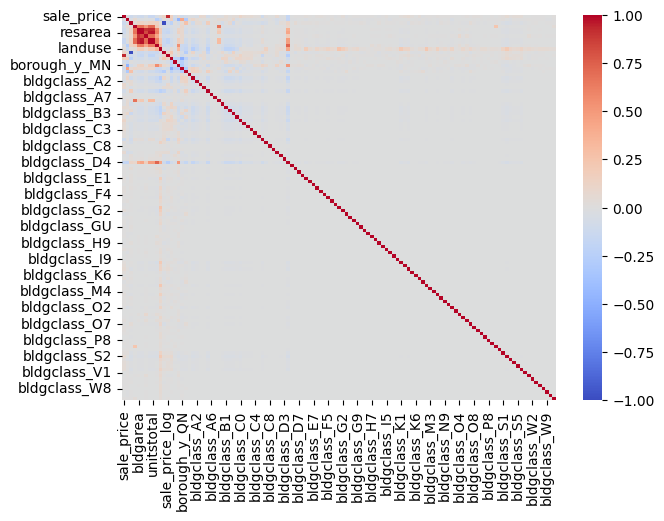

In [311]:
# This converts two categorical features into separate binary columns.
categorical_columns = ["borough_y","bldgclass"]

for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)

# NOTE: this will create a ton of columns, an that's ok! We'll let the
# colors do the talking.

# Correlation Heatmap with the new introduced variables.
correlations = df.corr( numeric_only=True)
plt.figure(figsize=(7,5))
sns.heatmap(correlations, cmap='coolwarm')


# Two observations:
# bldgclass_D4 appears to correlate with sale_price. I can't tell anything
# about the rest though.

<Axes: >

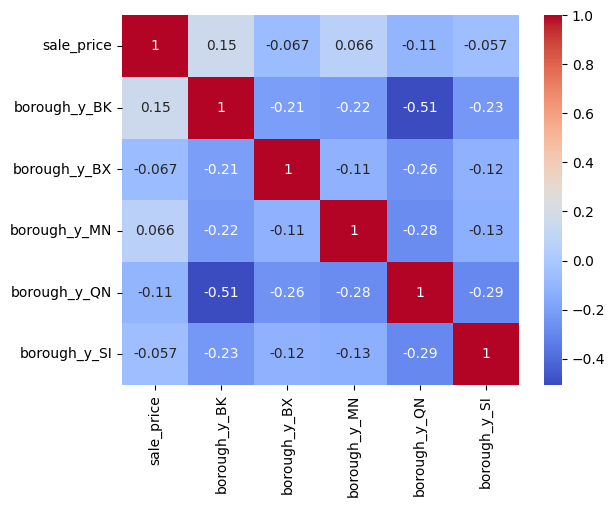

In [312]:
# Let's create a dataframe with only the boroughs so we can look at them
# more closely.

# Filtering
df_bclass = df[['sale_price',
         'borough_y_BK',
         'borough_y_BX',
         'borough_y_MN',
         'borough_y_QN',
         'borough_y_SI'
           ]]

# Creating another correlation heatmap
correlations = df_bclass.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, cmap='coolwarm')

# Looks like boroughs are not a great predictor to sale_price. Shame!

In [313]:
# Get all of the features with a high correlation value.
best_features = df.corr(numeric_only=True)['sale_price'].reset_index()

# Get the absolute value of the corr.
best_features['sale_price'] = abs(best_features['sale_price'])

# Retrieving the best possible features via the absolute values of their
# correlation values. 
best_features = best_features.sort_values("sale_price", ascending=False)
best_features = best_features[best_features["sale_price"] < 0.9]
best_features

,index,sale_price
45,bldgclass_D4,0.166149
13,borough_y_BK,0.152829
7,unitsres,0.143838
8,unitstotal,0.142472
5,resarea,0.115398
...,...,...
44,bldgclass_D3,0.001182
52,bldgclass_E7,0.000897
93,bldgclass_O5,0.000868
80,bldgclass_K6,0.000178


In [314]:
# And now we put this into a list. This will be the features we'll use
list_features = list(best_features['index'].head(50))
list_features

['bldgclass_D4',
 'borough_y_BK',
 'unitsres',
 'unitstotal',
 'resarea',
 'bldgclass_C0',
 'building_age',
 'yearbuilt',
 'borough_y_QN',
 'bldgclass_C6',
 'bldgarea',
 'bldgclass_A5',
 'bldgclass_A3',
 'bldgclass_D0',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_A4',
 'bldgclass_C1',
 'bldgclass_C3',
 'lotarea',
 'bldgclass_S2',
 'borough_y_SI',
 'bldgclass_K4',
 'bldgclass_B1',
 'bldgclass_A2',
 'comarea',
 'bldgclass_C2',
 'bldgclass_S9',
 'bldgclass_K2',
 'bldgclass_S5',
 'numfloors',
 'bldgclass_S4',
 'bldgclass_K7',
 'bldgclass_G2',
 'bldgclass_B3',
 'bldgclass_B9',
 'landuse',
 'bldgclass_K1',
 'bldgclass_A1',
 'bldgclass_E1',
 'bldgclass_F1',
 'bldgclass_K5',
 'bldgclass_I5',
 'bldgclass_C4',
 'bldgclass_G4',
 'bldgclass_E9',
 'bldgclass_A7',
 'bldgclass_A6',
 'bldgclass_B2',
 'bldgclass_C7']

#### FULL Correlation Matrix (With categorical columns)

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| Feature Engineering|
|3| <bold style="background:yellow;color:black;">ML Implementation</bold>|
|4| Model Application|


#### Linear Regression Model Creation

In [315]:
# Constants
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[list_features]
y = df['sale_price_log']

# Normalize the features (between zero and one!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test-split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=XY_SPLIT, random_state=101)

# Initializes the experiment in MLFLOW.
mlflow.set_experiment("ex1_project_a")

with mlflow.start_run():
    # Initalization
    lm = LinearRegression()
    lm.fit(X_train, y_train)

    # Find the intercept value of the regression
    intercept = lm.intercept_

    # Create a list of coefficients for each feature.
    coefs = lm.coef_
    print(coefs)

    # Predict the data with the model.
    predictions = lm.predict(X_test)

    # Get rid of the log transformation, converting it to dollars again.
    predictions = np.expm1(predictions)
    y_test = np.expm1(y_test)


    # -- METRICS RECORDING -- 
    mae = metrics.mean_absolute_error(y_test, predictions)
    mse = metrics.mean_squared_error(y_test, predictions)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
    r_sq = metrics.r2_score(y_test, predictions)

    # -- MLFLOW LOGGING --
    mlflow.set_tag("dataset", "kaggle_house_prices_v1")
    mlflow.set_tag("data_split", str(XY_SPLIT))
    mlflow.log_param("exercise_project_name","ex1_a")
    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("y_variable_truncation_amt", f"{y_trunc_floor, y_trunc_ceiling}")
    mlflow.log_param("features", str(X.columns))
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("r_squared", r_sq)
    mlflow.sklearn.log_model(lm, "model")



2026/01/20 23:50:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[-2.49624678e-01  2.33874202e-02 -2.04275592e+00  1.61293776e+00
  8.07373296e-01  7.67464828e-02  8.46440025e-03 -8.46440025e-03
 -3.58369847e-02 -1.07440340e-01 -4.84562975e-01  8.06235720e-03
  5.28072864e-02  9.65287438e-03 -5.40880126e-02  1.15937673e-01
  2.61636217e-02  2.31162291e-02  4.15143821e-02  4.99641353e-02
  2.81791150e-02 -4.25865915e-02  2.49273628e-02  6.04419888e-02
  1.51069188e-02 -2.03028345e-03  3.12381320e-02  1.08975253e-02
  2.41205870e-02  2.07879398e-02  1.24694133e-01  1.55564450e-02
  1.73345226e-02  2.17309102e-02  4.52148599e-02  3.36835548e-02
  2.50427421e-02  1.29843742e-02  3.89052064e-02  1.73995832e-02
  9.68071560e-03  1.18654108e-02  9.50731301e-03  1.60962013e-03
 -1.78260319e-02  9.62610042e-03  1.15452130e-02 -1.05643976e-02
  6.37802780e-02 -1.05416563e-02]


#### Metrics & Parameters

In [316]:
# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("Features Used:")
print(f"{(X.columns)} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}")



METRICS
--------------------------
MAE
391599.59 

MSE
359698377302.58 

RMSE
599748.6 

R-squared:
0.12 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.05, 0.95) 

Features Used:
Index(['bldgclass_D4', 'borough_y_BK', 'unitsres', 'unitstotal', 'resarea',
       'bldgclass_C0', 'building_age', 'yearbuilt', 'borough_y_QN',
       'bldgclass_C6', 'bldgarea', 'bldgclass_A5', 'bldgclass_A3',
       'bldgclass_D0', 'borough_y_BX', 'borough_y_MN', 'bldgclass_A4',
       'bldgclass_C1', 'bldgclass_C3', 'lotarea', 'bldgclass_S2',
       'borough_y_SI', 'bldgclass_K4', 'bldgclass_B1', 'bldgclass_A2',
       'comarea', 'bldgclass_C2', 'bldgclass_S9', 'bldgclass_K2',
       'bldgclass_S5', 'numfloors', 'bldgclass_S4', 'bldgclass_K7',
       'bldgclass_G2', 'bldgclass_B3', 'bldgclass_B9', 'landuse',
       'bldgclass_K1', 'bldgclass_A1', 'bldgclass_E1', 'bldgclass_F1',
       'bldgclass_K5', 'bldgclass_I5', 'bldgclass_C4', 'bldgclass_G4',
       'bldgclass_E9', 'bldgc

#### Scatterplot Linearity Test

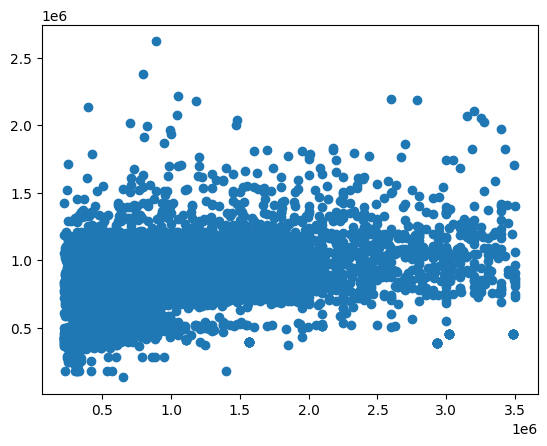

In [317]:
# If these values follow a line = good predictions
plt.scatter(y_test, predictions)
plt.show()

---

#### Model Application

|Step|Description|
|---|---|
|1|Data Cleaning|
|2| Feature Engineering|
|3| ML Implementation|
|4|<bold style="background:yellow;color:black;"> Model Application</bold>|